# Model and Evaluation (No Points Feature) for Approval Predict 

## Objective:

* Answer business requirement 2:
The client aims to offer a guide for potential applicants by identifying the influential factors that contribute to loan approval. These insights will be used to recommend specific improvements for applicants and guide them to increase their chances of having a loan approved.

* Test model performance without engineered points feature due to previous notebook identifying a 100% prediction accuracy. 

## Inputs
* outputs/datasets/collection/loan_approved.csv
* Instructions on which variables to use for data cleaning and feature engineering. They are found in each respective notebook.

## Outputs
* Train set (features and target)
* Test set (features and target)
* Machine learning pipeline including scaling & transformations
* Modeling pipeline
* Feature importance plot

## Imports and required libraries

In [1]:
# Core
import os
from pathlib import Path
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Sklearn: split, metrics, model selection
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, make_scorer
)

# Preprocessing & Pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from feature_engine.transformation import YeoJohnsonTransformer, BoxCoxTransformer

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, AdaBoostClassifier
)
from xgboost import XGBClassifier

# Imbalance
from imblearn.over_sampling import SMOTE

## Update Working Directory

In [2]:
current_dir = os.getcwd()
current_dir

'/workspaces/Approval_Predict/jupyter_notebooks'

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


In [4]:
current_dir = os.getcwd()
current_dir

'/workspaces/Approval_Predict'

## Load data

In [5]:
root = os.getcwd()
file_path = Path(root) / "outputs" / "datasets" / "collection" / "loan_approval.csv"
df = pd.read_csv(file_path).drop(['name', 'city'], axis=1)

df['loan_approved'] = df['loan_approved'].astype(int)
df['loan_to_income'] = df['loan_amount'] / df['income']

no__point_features = ['loan_to_income', 'credit_score', 'years_employed', 'loan_amount', 'income']
X = df[no__point_features].copy()
y = df['loan_approved'].copy()

X.head(3), y.head(3)

(   loan_to_income  credit_score  years_employed  loan_amount  income
 0        0.348809           389              27        39698  113810
 1        0.346385           729              28        15446   44592
 2        0.336228           584              13        11189   33278,
 0    0
 1    0
 2    0
 Name: loan_approved, dtype: int64)

## Split into Train/Test sets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

print("Train/Test Shapes:")
X_train.shape, y_train.shape, X_test.shape, y_test.shape

Train/Test Shapes:


((1600, 5), (1600,), (400, 5), (400,))

Handle Class Imbalance

After SMOTE: (1808, 5) (1808,)


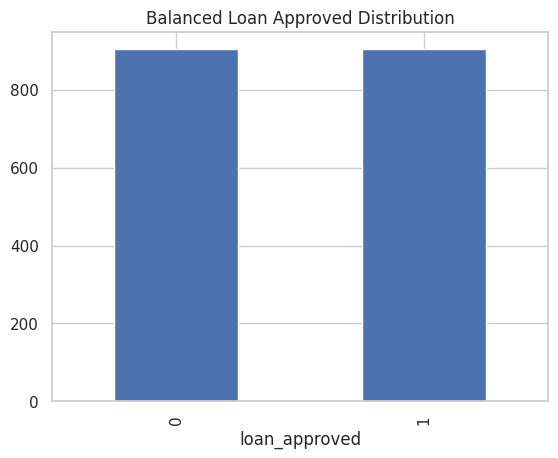

In [7]:
smote = SMOTE(sampling_strategy='minority', random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After SMOTE:", X_train_bal.shape, y_train_bal.shape)

y_train_bal.value_counts().plot(kind='bar', title='Balanced Loan Approved Distribution')
plt.show()

Build ML pipeline

In [8]:
def loan_approval_pipeline(model):
    """
    Create a machine learning pipeline that applies Box-Cox
    transformations, robust scaling, and a classification model for predicting
    loan approval.
    
    """
    
    pipeline = Pipeline([
        ('boxcox', BoxCoxTransformer(variables=['loan_to_income'])),
        ('scaler', RobustScaler()),
        ('model', model)
    ])
    
    return pipeline

In [9]:
def PipelineClf(model):
    """
    Builds a pipeline for hyperparameter optimisation that includes
    feature transformations, robust scaling and a classifier model.
    """
    return Pipeline([
        ("boxcox", BoxCoxTransformer(variables=['loan_to_income'])),
        ("scaler", RobustScaler()),
        ("model", model),
    ])

Grid search

In [10]:
models_quick_search = {
    "LogisticRegression": LogisticRegression(random_state=42),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "RandomForestClassifier": RandomForestClassifier(random_state=42),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
    "ExtraTreesClassifier": ExtraTreesClassifier(random_state=42),
    "AdaBoostClassifier": AdaBoostClassifier(random_state=42),
    "XGBClassifier": XGBClassifier(random_state=42)
}

params_quick_search = {
    "LogisticRegression": {},
    "DecisionTreeClassifier": {},
    "RandomForestClassifier": {},
    "GradientBoostingClassifier": {},
    "ExtraTreesClassifier": {},
    "AdaBoostClassifier": {},
    "XGBClassifier": {},
}


Custom function for grid search

In [11]:
class HyperparameterOptimizationSearch:

    def __init__(self, models, params):
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, X, y, cv, n_jobs, verbose=1, scoring=None, refit=False):
        for key in self.keys:
            print(f"\nRunning GridSearchCV for {key} \n")

            model = PipelineClf(self.models[key])
            params = self.params[key]
            gs = GridSearchCV(model, params, cv=cv, n_jobs=n_jobs,
                              verbose=verbose, scoring=scoring, )
            gs.fit(X, y)
            self.grid_searches[key] = gs

    def score_summary(self, sort_by='mean_score'):
        def row(key, scores, params):
            d = {
                'estimator': key,
                'min_score': min(scores),
                'max_score': max(scores),
                'mean_score': np.mean(scores),
                'std_score': np.std(scores),
            }
            return pd.Series({**params, **d})

        rows = []
        for k in self.grid_searches:
            params = self.grid_searches[k].cv_results_['params']
            scores = []
            for i in range(self.grid_searches[k].cv):
                key = "split{}_test_score".format(i)
                r = self.grid_searches[k].cv_results_[key]
                scores.append(r.reshape(len(params), 1))

            all_scores = np.hstack(scores)
            for p, s in zip(params, all_scores):
                rows.append((row(k, s, p)))

        df = pd.concat(rows, axis=1).T.sort_values([sort_by], ascending=False)
        columns = ['estimator', 'min_score',
                   'mean_score', 'max_score', 'std_score']
        columns = columns + [c for c in df.columns if c not in columns]
        return df[columns], self.grid_searches


In [12]:
search = HyperparameterOptimizationSearch(
    models=models_quick_search,
    params=params_quick_search
)

search.fit(
    X_train_bal,
    y_train_bal,
    scoring=make_scorer(recall_score, pos_label=1),
    cv=5,
    n_jobs=-1,
    verbose=1
)


Running GridSearchCV for LogisticRegression 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for DecisionTreeClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for RandomForestClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for GradientBoostingClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for ExtraTreesClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for AdaBoostClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for XGBClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_spars

In [13]:
results_summary, search_pipelines = search.score_summary(sort_by='mean_score')
display(results_summary)

,estimator,min_score,mean_score,max_score,std_score
2,RandomForestClassifier,0.977778,0.991136,1.0,0.007538
5,AdaBoostClassifier,0.977778,0.991136,1.0,0.009013
6,XGBClassifier,0.977778,0.991136,1.0,0.008308
3,GradientBoostingClassifier,0.977778,0.990031,1.0,0.010157
4,ExtraTreesClassifier,0.977778,0.987821,1.0,0.007363
1,DecisionTreeClassifier,0.961326,0.977864,0.994475,0.014006
0,LogisticRegression,0.888889,0.920319,0.933702,0.016099


In [14]:
best_model = results_summary.iloc[0, 0]
pipeline_clf = search.grid_searches[best_model].best_estimator_
pipeline_clf

Pipeline(steps=[('boxcox', BoxCoxTransformer(variables=['loan_to_income'])),
                ('scaler', RobustScaler()),
                ('model', RandomForestClassifier(random_state=42))])

Hyperparameter search

In [ ]:
def confusion_matrix_and_report(X, y, pipeline, label_map):
    prediction = pipeline.predict(X)

    print('---  Confusion Matrix  ---')
    print(pd.DataFrame(
        confusion_matrix(y_true=prediction, y_pred=y),
        columns=[["Actual " + sub for sub in label_map]],
        index=[["Prediction " + sub for sub in label_map]]
    ))
    print("\n")

    print('---  Classification Report  ---')
    print(classification_report(y, prediction, target_names=label_map), "\n")

def clf_performance(X_train, y_train, X_test, y_test, pipeline, label_map):
    print("#### Train Set #### \n")
    confusion_matrix_and_report(X_train, y_train, pipeline, label_map)

    print("#### Test Set ####\n")
    confusion_matrix_and_report(X_test, y_test, pipeline, label_map)

In [18]:
print(f"Quick-search best model: {best_model}")

clf_performance(
    X_train_bal, y_train_bal,
    X_test, y_test,
    pipeline_clf,
    label_map=["Rejected", "Approved"]
)

Quick-search best model: RandomForestClassifier
#### Train Set #### 

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             904               0
Prediction Approved               0             904


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       904
    Approved       1.00      1.00      1.00       904

    accuracy                           1.00      1808
   macro avg       1.00      1.00      1.00      1808
weighted avg       1.00      1.00      1.00      1808
 

#### Test Set ####

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             213               3
Prediction Approved               4             180


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.99      0.98      0.98       217
    Approved       0.98      0.98     

          Feature  Importance
1    credit_score    0.672414
4          income    0.121335
0  loan_to_income    0.110178
2  years_employed    0.054567
3     loan_amount    0.041505


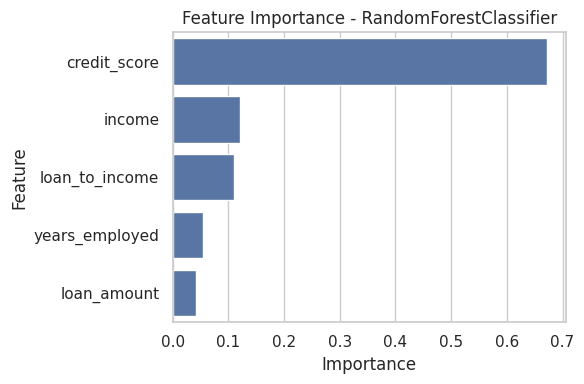

In [19]:
model_step = pipeline_clf.named_steps['model']

# Get feature names used in training
feature_names = X_train_bal.columns

# Create importance dataframe
feature_importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": model_step.feature_importances_
    })
    .sort_values(by="Importance", ascending=False)
)

print(feature_importance_df)

# Plot importance
plt.figure(figsize=(6,4))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - RandomForestClassifier")
plt.tight_layout()
plt.show()